In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from scipy.integrate import quad
from scipy.interpolate import splev, splrep
from scipy.optimize import brute, fmin
from scipy.integrate import quad
from collections import Counter
from scipy.optimize import minimize
import scipy.optimize as opt
from scipy.fftpack import fft

**Step 1**

In [ ]:
# Constants
RISK_FREE_RATE = 0.015  # Annual risk-free rate (r=1.5%)
TRADING_DAYS = 250  # Number of trading days in a year
S0 = 232.9  # Current stock price

In [ ]:
#market data
data = pd.read_excel('MScFE 622_Stochastic Modeling_GWP1_Option data.xlsx')
data.head()

,Days to maturity,Strike,Price,Type
0,15,227.5,10.52,C
1,15,230.0,10.05,C
2,15,232.5,7.75,C
3,15,235.0,6.01,C
4,15,237.5,4.75,C


In [ ]:
# Pivot the data to have call and put prices in separate columns
df_pivot = data.pivot_table(index=['Strike', 'Days to maturity'], columns='Type', values='Price').reset_index()

# Rename columns for clarity
df_pivot.columns = ['Strike',  'Days to Maturity',  'Call', 'Put']

# Display the transformed dataset
display(df_pivot)

,Strike,Days to Maturity,Call,Put
0,227.5,15,10.52,4.320000
1,227.5,60,16.78,11.030000
2,227.5,120,27.92,14.530629
3,230.0,15,10.05,5.200000
4,230.0,60,17.65,12.150000
5,230.0,120,24.12,16.250000
6,232.5,15,7.75,6.450000
7,232.5,60,16.86,13.370000
8,232.5,120,22.97,17.220000
9,235.0,15,6.01,7.560000


In [ ]:
# Adding  constant short-rates
options = df_pivot.copy()
for row, option in options.iterrows():
  T = option["Days to Maturity"] / 250.0
  options.loc[row, "T"] = T
  options.loc[row, "r"] = 0.015

In [ ]:
options = options[options['Days to Maturity'] == 15]

In [ ]:
options.head()

,Strike,Days to Maturity,Call,Put,T,r
0,227.5,15,10.52,4.32,0.06,0.015
3,230.0,15,10.05,5.20,0.06,0.015
6,232.5,15,7.75,6.45,0.06,0.015
9,235.0,15,6.01,7.56,0.06,0.015
12,237.5,15,4.75,8.78,0.06,0.015


**Step 1.1**

In [ ]:
i = 0
min_MSE = 500

In [ ]:
def H93_error_function(p0):
    """Error function for parameter calibration via
    Lewis (2001) Fourier approach for Heston (1993).
    Parameters
    ==========
    kappa_v: float
        mean-reversion factor
    theta_v: float
        long-run mean of variance
    sigma_v: float
        volatility of variance
    rho: float
        correlation between variance and stock/index level
    v0: float
        initial, instantaneous variance
    Returns
    =======
    MSE: float
        mean squared error
    """
    global i, min_MSE
    kappa_v, theta_v, sigma_v, rho, v0 = p0
    if kappa_v < 0.0 or theta_v < 0.005 or sigma_v < 0.0 or rho < -1.0 or rho > 1.0:
        return 500.0
    if 2 * kappa_v * theta_v < sigma_v**2:
        return 500.0
    se = []
    for row, option in options.iterrows():
        model_value = H93_call_value(
            S0,
            option["Strike"],
            option["T"],
            option["r"],
            kappa_v,
            theta_v,
            sigma_v,
            rho,
            v0,
        )
        se.append((model_value - option["Call"]) ** 2)
    MSE = sum(se) / len(se)
    min_MSE = min(min_MSE, MSE)
    if i % 25 == 0:
        print("%4d |" % i, np.array(p0), "| %7.3f | %7.3f" % (MSE, min_MSE))
    i += 1
    return MSE

In [ ]:
def H93_char_func(u, T, r, kappa_v, theta_v, sigma_v, rho, v0):
    """Valuation of European call option in H93 model via Lewis (2001)
    Fourier-based approach: characteristic function.
    Parameter definitions see function BCC_call_value."""
    c1 = kappa_v * theta_v
    c2 = -np.sqrt(
        (rho * sigma_v * u * 1j - kappa_v) ** 2 - sigma_v**2 * (-u * 1j - u**2)
    )
    c3 = (kappa_v - rho * sigma_v * u * 1j + c2) / (
        kappa_v - rho * sigma_v * u * 1j - c2
    )
    H1 = r * u * 1j * T + (c1 / sigma_v**2) * (
        (kappa_v - rho * sigma_v * u * 1j + c2) * T
        - 2 * np.log((1 - c3 * np.exp(c2 * T)) / (1 - c3))
    )
    H2 = (
        (kappa_v - rho * sigma_v * u * 1j + c2)
        / sigma_v**2
        * ((1 - np.exp(c2 * T)) / (1 - c3 * np.exp(c2 * T)))
    )
    char_func_value = np.exp(H1 + H2 * v0)
    return char_func_value

In [ ]:
def H93_int_func(u, S0, K, T, r, kappa_v, theta_v, sigma_v, rho, v0):
    """
    Fourier-based approach for Lewis (2001): Integration function.
    """
    char_func_value = H93_char_func(
        u - 1j * 0.5, T, r, kappa_v, theta_v, sigma_v, rho, v0
    )
    int_func_value = (
        1 / (u**2 + 0.25) * (np.exp(1j * u * np.log(S0 / K)) * char_func_value).real
    )
    return int_func_value

In [ ]:
def H93_call_value(S0, K, T, r, kappa_v, theta_v, sigma_v, rho, v0):
    """Valuation of European call option in H93 model via Lewis (2001)

    Parameter definition:
    ==========
    S0: float
        initial stock/index level
    K: float
        strike price
    T: float
        time-to-maturity (for t=0)
    r: float
        constant risk-free short rate
    kappa_v: float
        mean-reversion factor
    theta_v: float
        long-run mean of variance
    sigma_v: float
        volatility of variance
    rho: float
        correlation between variance and stock/index level
    v0: float
        initial level of variance
    Returns
    =======
    call_value: float
        present value of European call option
    """
    int_value = quad(
        lambda u: H93_int_func(u, S0, K, T, r, kappa_v, theta_v, sigma_v, rho, v0),
        0,
        np.inf,
        limit=250,
    )[0]
    call_value = max(0, S0 - np.exp(-r * T) * np.sqrt(S0 * K) / np.pi * int_value)
    return call_value

In [ ]:
def H93_calibration_full():
    """Calibrates Heston (1993) stochastic volatility model to market quotes."""
    # First run with brute force
    # (scan sensible regions, for faster convergence)
    p0 = brute(
        H93_error_function,
        (
            (2.5, 10.6, 5.0),  # kappa_v
            (0.01, 0.041, 0.01),  # theta_v
            (0.05, 0.251, 0.1),  # sigma_v
            (-0.75, 0.01, 0.25),  # rho
            (0.01, 0.031, 0.01),
        ),  # v0
        finish=None,
    )

    # Second run with local, convex minimization
    # (we dig deeper where promising results)
    opt = fmin(
        H93_error_function, p0, xtol=0.000001, ftol=0.000001, maxiter=750, maxfun=900
    )
    return opt

In [ ]:
def H93_calculate_model_values(p0):
    kappa_v, theta_v, sigma_v, rho, v0 = p0
    values = []
    for row, option in options.iterrows():
        model_value = H93_call_value(
            S0,
            option["Strike"],
            option["T"],
            option["r"],
            kappa_v,
            theta_v,
            sigma_v,
            rho,
            v0
        )

        values.append(model_value)

    return np.array(values)

In [ ]:
def plot_full_calibration_results(p0):
    options["Model"] = H93_calculate_model_values(p0)
    plt.figure(figsize=(8, 6))
    plt.subplot(211)
    plt.grid()
    plt.title("Maturity %s" % str(options["Days to Maturity"].iloc[0])[:10])
    plt.ylabel("option values")
    plt.plot(options.Strike, options.Call, "b", label="market")
    plt.plot(options.Strike, options.Model, "ro", label="model")
    plt.legend(loc=0)
    plt.axis(
        [
            min(options.Strike) - 10,
            max(options.Strike) + 10,
            min(options.Call) - 10,
            max(options.Call) + 10,
        ]
    )
    plt.subplot(212)
    plt.grid()
    wi = 5.0
    diffs = options.Model.values - options.Call.values
    plt.bar(options.Strike.values - wi / 2, diffs, width=wi)
    plt.ylabel("difference")
    plt.axis(
        [
            min(options.Strike) - 10,
            max(options.Strike) + 10,
            min(diffs) * 1.1,
            max(diffs) * 1.1,
        ]
    )
    plt.tight_layout()

In [ ]:
opt_params = H93_calibration_full()

 875 | [ 2.5   0.01  0.05 -0.75  0.01] |  23.560 |   0.378
 900 | [ 2.5   0.02  0.05 -0.75  0.02] |  16.264 |   0.378
 925 | [ 2.5   0.02  0.25 -0.75  0.03] |  11.689 |   0.378
 950 | [ 2.5   0.03  0.15 -0.5   0.01] |  22.320 |   0.378
 975 | [ 2.5   0.04  0.05 -0.5   0.02] |  15.462 |   0.378
1000 | [ 2.5   0.04  0.25 -0.5   0.03] |  11.135 |   0.378
1025 | [ 7.5   0.01  0.15 -0.25  0.01] |  23.608 |   0.378
1050 | [ 7.5   0.02  0.05 -0.25  0.02] |  16.283 |   0.378
1075 | [ 7.5   0.02  0.25 -0.25  0.03] |  12.271 |   0.378
1100 | [7.5  0.03 0.15 0.   0.01] |  20.385 |   0.378
1125 | [7.5  0.04 0.05 0.   0.02] |  14.175 |   0.378
1150 | [7.5  0.04 0.25 0.   0.03] |  10.699 |   0.378
1175 | [ 7.10037179  0.05742843  0.11352214 -0.46596154  0.04611934] |   5.735 |   0.378
1200 | [4.40533337 0.12535142 0.0295268  0.88059866 0.1090853 ] |   0.422 |   0.378
1225 | [4.61442166 0.12165979 0.0273206  0.75145539 0.10338613] |   0.382 |   0.378
1250 | [4.59781487 0.12096663 0.02707868 0.7266005

<ipython-input-33-277e0d7e46d1>:29: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  int_value = quad(


1300 | [3.11416214e+00 1.24592879e-01 1.05443179e-03 6.16838223e-01
 1.03272892e-01] |   0.378 |   0.378
1325 | [3.05816719e+00 1.24815986e-01 2.59029072e-05 6.11844876e-01
 1.03346090e-01] |   0.378 |   0.378
1350 | [3.04884645e+00 1.24761041e-01 2.89505546e-06 6.14850388e-01
 1.03345140e-01] |   0.378 |   0.378
1375 | [3.04750647e+00 1.24755280e-01 4.34807211e-06 6.15508253e-01
 1.03348326e-01] |   0.378 |   0.378
1400 | [3.04732482e+00 1.24756830e-01 4.11644132e-06 6.15624254e-01
 1.03350321e-01] |   0.378 |   0.378
1425 | [3.04732015e+00 1.24756684e-01 4.10274251e-06 6.15622837e-01
 1.03350233e-01] |   0.378 |   0.378
1450 | [3.04732613e+00 1.24756721e-01 4.11084266e-06 6.15620735e-01
 1.03350232e-01] |   0.378 |   0.378
1475 | [3.04732415e+00 1.24756712e-01 4.10885546e-06 6.15621511e-01
 1.03350235e-01] |   0.378 |   0.378
1500 | [3.04732412e+00 1.24756711e-01 4.10869046e-06 6.15621494e-01
 1.03350234e-01] |   0.378 |   0.378
1525 | [3.04732414e+00 1.24756711e-01 4.10870391e-06 6.

In [ ]:
opt_params

array([3.04732414e+00, 1.24756711e-01, 4.10870537e-06, 6.15621485e-01,
       1.03350234e-01])

<ipython-input-33-277e0d7e46d1>:29: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  int_value = quad(


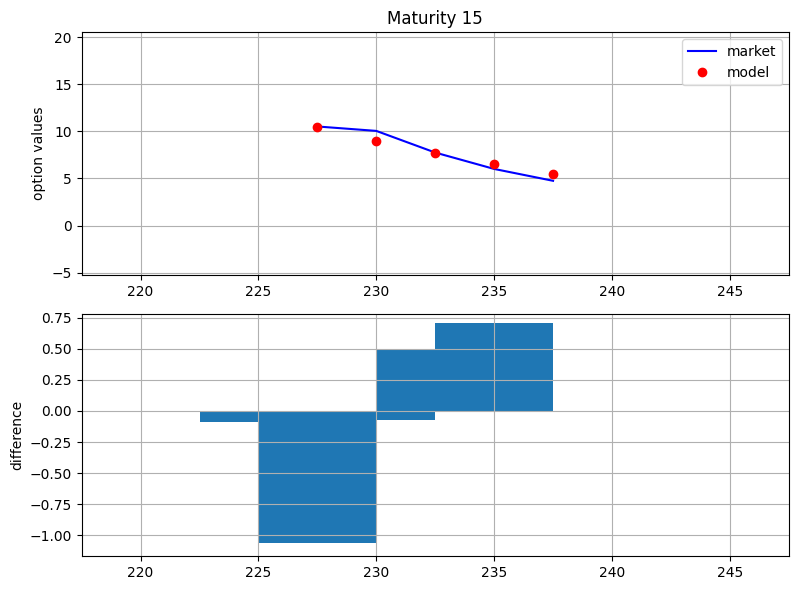

In [ ]:
plot_full_calibration_results(opt_params)

**Q1.3: ATM Asian Call Option Using Monte Carlo**

Asian option: The payoff depends on the average of the underlying stock prices over a period.

ATM (At-the-money): The strike price is set equal to the current stock price (i.e., 𝐾=𝑆0=232.90

Maturity: The option matures in 20 days.

In [ ]:
# Option Parameters
S0 = 232.9
K = S0
T = 0.06
r = 0.015

In [ ]:
n_simulations = 100000  # Number of Monte Carlo simulations
n_timesteps = 15
dt = T / n_timesteps

In [ ]:
# Monte Carlo simulation of Heston model paths
def simulate_heston_paths(S0, K, T, r, kappa, theta, sigma_v, rho, v0, n_simulations, n_timesteps):
    dt = T / n_timesteps
    asset_prices = np.zeros((n_simulations, n_timesteps + 1))
    variances = np.zeros((n_simulations, n_timesteps + 1))

    asset_prices[:, 0] = S0
    variances[:, 0] = v0

    # Simulate paths
    for t in range(1, n_timesteps + 1):
        Z1 = np.random.randn(n_simulations)  # Brownian motion for S
        Z2 = np.random.randn(n_simulations)  # Brownian motion for v
        W1 = Z1
        W2 = rho * Z1 + np.sqrt(1 - rho**2) * Z2  # Correlated Brownian motion

        # Variance update using the Heston variance dynamics
        variances[:, t] = np.maximum(variances[:, t-1] + kappa * (theta - variances[:, t-1]) * dt + sigma_v * np.sqrt(variances[:, t-1] * dt) * W2, 0)

        # Asset price update using the Heston asset dynamics
        asset_prices[:, t] = asset_prices[:, t-1] * np.exp((r - 0.5 * variances[:, t-1]) * dt + np.sqrt(variances[:, t-1] * dt) * W1)

    return asset_prices

# Calculate the fair price of the Asian call option
def price_asian_call_heston(S0, K, T, r, kappa, theta, sigma_v, rho, v0, n_simulations, n_timesteps):
    asset_prices = simulate_heston_paths(S0, K, T, r, kappa, theta, sigma_v, rho, v0, n_simulations, n_timesteps)

    # Calculate average price over all timesteps for each simulation
    average_prices = np.mean(asset_prices[:, 0:], axis=1)

    # Calculate the payoff for each simulation
    payoffs = np.maximum(average_prices - K, 0)

    # Discount the payoffs back to present value
    discounted_payoff = np.exp(-r * T) * payoffs

    # Fair price is the average discounted payoff
    fair_price = np.mean(discounted_payoff)

    return fair_price

**Place the Heston Parameters from Step 1.1**

In [ ]:
# Heston(1993) Parameters
kappa = 3.0473
theta = 0.12475
sigma_v = 0.0000041087
rho = 0.61562
v0 = 0.10335

**ii: Client Price After Adding 4% Fee**

Once we have the fair price of the option from the Monte Carlo simulation, we can add a 4% fee:

Final Price=Fair Price×(1+0.04)

This fee represents the profit the bank charges on top of the option's fair value.

In [ ]:
# Part i: Get the fair price of the ATM Asian call option
fair_price_asian_call = price_asian_call_heston(S0, K, T, r, kappa, theta, sigma_v, rho, v0, n_simulations, n_timesteps)
print(f"Fair price of the Asian call option: {fair_price_asian_call:.2f}")

# Part ii: Final price with 4% fee
final_price = fair_price_asian_call * 1.04
print(f"Final price for the client (including 4% fee): {final_price:.2f}")

Fair price of the Asian call option: 4.20
Final price for the client (including 4% fee): 4.36


**Step 2**

Q2.1 the case at hand (60-day maturity instrument) using a Heston model with jumps (i.e., Bates, 1996 model). with Lewis(2001) approach

**Data Processing**

In [ ]:
option_data2 = options.copy()
option_data2.head()

,Strike,Days to Maturity,Call,Put,T,r,Model
0,227.5,15,10.52,4.32,0.06,0.015,10.433055
3,230.0,15,10.05,5.20,0.06,0.015,8.988365
6,232.5,15,7.75,6.45,0.06,0.015,7.678472
9,235.0,15,6.01,7.56,0.06,0.015,6.503400
12,237.5,15,4.75,8.78,0.06,0.015,5.460249


In [ ]:
tol = 0.02  # Tolerance level to select ATM options (percent around ITM/OTM options)
option_data3 = option_data2[(np.abs(option_data2["Strike"] - S0) / S0) < tol]
option_data3.head()

,Strike,Days to Maturity,Call,Put,T,r,Model
3,230.0,15,10.05,5.20,0.06,0.015,8.988365
6,232.5,15,7.75,6.45,0.06,0.015,7.678472
9,235.0,15,6.01,7.56,0.06,0.015,6.503400
12,237.5,15,4.75,8.78,0.06,0.015,5.460249


In [ ]:
#option_data_wide = option_data3.pivot( columns='Type', values='Strike')
option_data_step21 =option_data3.copy()
option_data_step21['Days to Maturity'] = 60
option_data_step21.head()

,Strike,Days to Maturity,Call,Put,T,r,Model
3,230.0,60,10.05,5.20,0.06,0.015,8.988365
6,232.5,60,7.75,6.45,0.06,0.015,7.678472
9,235.0,60,6.01,7.56,0.06,0.015,6.503400
12,237.5,60,4.75,8.78,0.06,0.015,5.460249


In [ ]:
# Market and general parameters
S0 = 232.90
RISK_FREE_RATE = 0.015
DAYS_IN_YEAR = 250

In [ ]:
# Heston(1993) Parameters using LeWIs from Step 1.1
kappa_v = 3.0473
theta_v = 0.12475
sigma_v = 0.0000041087
rho = 0.61562
v0 = 0.10335

In [ ]:
lambda_jump, mu_jump, sigma_jump = [0.1, 0.01, 0.02]  # Jump parameters (initial guesses)

In [ ]:
def B96_error_function(p0):
    """
    Error function for Bates (1996) model

    Parameters:
    -------------
    lamb: float
        jump intensity
    mu: float
        expected jump size
    delta: float
        standard deviation of jump
    Returns
    -------------
    MSE: float
        mean squared error
    """

    global i, min_MSE, local_opt, opt1
    lamb, mu, delta = p0
    if lamb < 0.0 or mu < -0.6 or mu > 0.0 or delta < 0.0:
        return 5000.0
    se = []
    for row, option in option_data_step21.iterrows():
        model_value = B96_call_value(
            S0,
            option["Strike"],
            option["T"],
            option["r"],
            kappa_v,
            theta_v,
            sigma_v,
            rho,
            v0,
            lamb,
            mu,
            delta,
        )
        se.append((model_value - option["Call"]) ** 2)
    MSE = sum(se) / len(se)
    min_MSE = min(min_MSE, MSE)
    if i % 50 == 0:
        print("%4d |" % i, np.array(p0), "| %7.3f | %7.3f" % (MSE, min_MSE))
    i += 1
    if local_opt:
        penalty = np.sqrt(np.sum((p0 - opt1) ** 2)) * 1
        return MSE + penalty
    return MSE

In [ ]:
def B96_call_value(S0, K, T, r, kappa_v, theta_v, sigma_v, rho, v0, lamb, mu, delta):
    """
    Valuation of European call option in B96 Model via Lewis (2001)
    Parameters:
    ==========
    S0: float
        initial stock/index level
    K: float
        strike price
    T: float
        time-to-maturity (for t=0)
    r: float
        constant risk-free short rate
    kappa_v: float
        mean-reversion factor
    theta_v: float
        long-run mean of variance
    sigma_v: float
        volatility of variance
    rho: float
        correlation between variance and stock/index level
    v0: float
        initial level of variance
    lamb: float
        jump intensity
    mu: float
        expected jump size
    delta: float
        standard deviation of jump
    ==========
    """
    int_value = quad(
        lambda u: B96_int_func(
            u, S0, K, T, r, kappa_v, theta_v, sigma_v, rho, v0, lamb, mu, delta
        ),
        0,
        np.inf,
        limit=250,
    )[0]
    call_value = max(0, S0 - np.exp(-r * T) * np.sqrt(S0 * K) / np.pi * int_value)
    return call_value

In [ ]:
def H93_char_func(u, T, r, kappa_v, theta_v, sigma_v, rho, v0):
    """Valuation of European call option in H93 model via Lewis (2001)
    Fourier-based approach: characteristic function.
    Parameter definitions see function BCC_call_value."""
    c1 = kappa_v * theta_v
    c2 = -np.sqrt(
        (rho * sigma_v * u * 1j - kappa_v) ** 2 - sigma_v**2 * (-u * 1j - u**2)
    )
    c3 = (kappa_v - rho * sigma_v * u * 1j + c2) / (
        kappa_v - rho * sigma_v * u * 1j - c2
    )
    H1 = r * u * 1j * T + (c1 / sigma_v**2) * (
        (kappa_v - rho * sigma_v * u * 1j + c2) * T
        - 2 * np.log((1 - c3 * np.exp(c2 * T)) / (1 - c3))
    )
    H2 = (
        (kappa_v - rho * sigma_v * u * 1j + c2)
        / sigma_v**2
        * ((1 - np.exp(c2 * T)) / (1 - c3 * np.exp(c2 * T)))
    )
    char_func_value = np.exp(H1 + H2 * v0)
    return char_func_value

In [ ]:
def M76J_char_func(u, T, lamb, mu, delta):
    """
    Adjusted Characteristic function for Merton '76 model: Only jump component
    """

    omega = -lamb * (np.exp(mu + 0.5 * delta**2) - 1)
    char_func_value = np.exp(
        (1j * u * omega + lamb * (np.exp(1j * u * mu - u**2 * delta**2 * 0.5) - 1))
        * T
    )
    return char_func_value

In [ ]:
def B96_char_func(u, T, r, kappa_v, theta_v, sigma_v, rho, v0, lamb, mu, delta):
    """
    Bates (1996) characteristic function
    """
    H93 = H93_char_func(u, T, r, kappa_v, theta_v, sigma_v, rho, v0)
    M76J = M76J_char_func(u, T, lamb, mu, delta)
    return H93 * M76J

In [ ]:
def B96_int_func(u, S0, K, T, r, kappa_v, theta_v, sigma_v, rho, v0, lamb, mu, delta):
    """
    Lewis (2001) integral value for Bates (1996) characteristic function
    """
    char_func_value = B96_char_func(
        u - 1j * 0.5, T, r, kappa_v, theta_v, sigma_v, rho, v0, lamb, mu, delta
    )
    int_func_value = (
        1 / (u**2 + 0.25) * (np.exp(1j * u * np.log(S0 / K)) * char_func_value).real
    )
    return int_func_value

In [ ]:
def B96_calibration_short():
    """
    Calibrates jump component of Bates (1996) model to market prices
    """
    # First, we run with brute force
    # (scan sensible regions)
    opt1 = 0.0
    opt1 = brute(
        B96_error_function,
        (
            (0.01, 0.51, 0.05),  # lambda
            (-0.5, 0.11, 0.05),  # mu
            (0.01, 0.51, 0.05),
        ),  # delta
        finish=None,
    )

    # Second, we run with local, convex minimization
    # (dig deeper where promising)
    opt2 = fmin(
        B96_error_function,
        opt1,
        xtol=0.0000001,
        ftol=0.0000001,
        maxiter=550,
        maxfun=750,
    )
    return opt2

In [ ]:
def B96_jump_calculate_model_values(p0):
    """Calculates all model values given parameter vector p0."""
    lamb, mu, delta = p0
    values = []
    for row, option in option_data_step21.iterrows():
        T = option["T"]
        r = option["r"]
        model_value = B96_call_value(
            S0,
            option["Strike"],
            T,
            r,
            kappa_v,
            theta_v,
            sigma_v,
            rho,
            v0,
            lamb,
            mu,
            delta,
        )
        values.append(model_value)
    return np.array(values)

In [ ]:
def plot_calibration_results(p0):
    option_data_step21["Model"] = B96_jump_calculate_model_values(p0)
    plt.figure(figsize=(8, 6))
    plt.subplot(211)
    plt.grid()
    plt.title("Maturity %s" % str(option_data_step21["Days to Maturity"].iloc[0])[:10])
    plt.ylabel("option values")
    plt.plot(option_data_step21.Strike, option_data_step21.Call, "b", label="market")
    plt.plot(option_data_step21.Strike, option_data_step21.Model, "ro", label="model")
    plt.legend(loc=0)
    plt.axis(
        [
            min(option_data_step21.Strike) - 10,
            max(option_data_step21.Strike) + 10,
            min(option_data_step21.Call) - 10,
            max(option_data_step21.Call) + 10,
        ]
    )
    plt.subplot(212)
    plt.grid()
    wi = 5.0
    diffs = option_data_step21.Model.values -option_data_step21.Call.values
    plt.bar(option_data_step21.Strike.values - wi / 2, diffs, width=wi)
    plt.ylabel("difference")
    plt.axis(
        [
            min(option_data_step21.Strike) - 10,
            max(option_data_step21.Strike) + 10,
            min(diffs) * 1.1,
            max(diffs) * 1.1,
        ]
    )
    plt.tight_layout()

In [ ]:
i = 0
min_MSE = 5000.0
local_opt = False

In [ ]:
params1 = B96_calibration_short()

<ipython-input-50-e06401f36e4a>:32: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  int_value = quad(


   0 | [ 0.01 -0.5   0.01] |   0.468 |   0.468
  50 | [ 0.01 -0.25  0.01] |   0.469 |   0.468
 100 | [0.01 0.   0.01] |   0.470 |   0.468
 150 | [ 0.06 -0.3   0.01] |   0.469 |   0.468
 200 | [ 0.06 -0.05  0.01] |   0.470 |   0.468
 250 | [ 0.11 -0.35  0.01] |   0.486 |   0.468
 300 | [ 0.11 -0.1   0.01] |   0.470 |   0.468
 350 | [ 0.16 -0.4   0.01] |   0.534 |   0.468
 400 | [ 0.16 -0.15  0.01] |   0.473 |   0.468
 450 | [ 0.21 -0.45  0.01] |   0.631 |   0.468
 500 | [ 0.21 -0.2   0.01] |   0.489 |   0.468
 550 | [ 0.26 -0.5   0.01] |   0.797 |   0.468
 600 | [ 0.26 -0.25  0.01] |   0.533 |   0.468
 650 | [0.26 0.   0.01] |   0.470 |   0.468
 700 | [ 0.31 -0.3   0.01] |   0.623 |   0.468
 750 | [ 0.31 -0.05  0.01] |   0.471 |   0.468
 800 | [ 0.36 -0.35  0.01] |   0.781 |   0.468
 850 | [ 0.36 -0.1   0.01] |   0.477 |   0.468
 900 | [ 0.41 -0.4   0.01] |   1.030 |   0.468
 950 | [ 0.41 -0.15  0.01] |   0.510 |   0.468
1000 | [ 0.46 -0.45  0.01] |   1.396 |   0.468
1050 | [ 0.46 -0.2 

In [ ]:
params1

array([ 0.01924651, -0.59999983,  0.00162885])

In [ ]:
lamb = 0.01924651
mu = -0.59999983
delta = 0.00162885

In [ ]:
kappa_v, theta_v, sigma_v, rho, v0, lamb, mu, delta

(3.0473,
 0.12475,
 4.1087e-06,
 0.61562,
 0.10335,
 0.01924651,
 -0.59999983,
 0.00162885)

<ipython-input-50-e06401f36e4a>:32: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  int_value = quad(


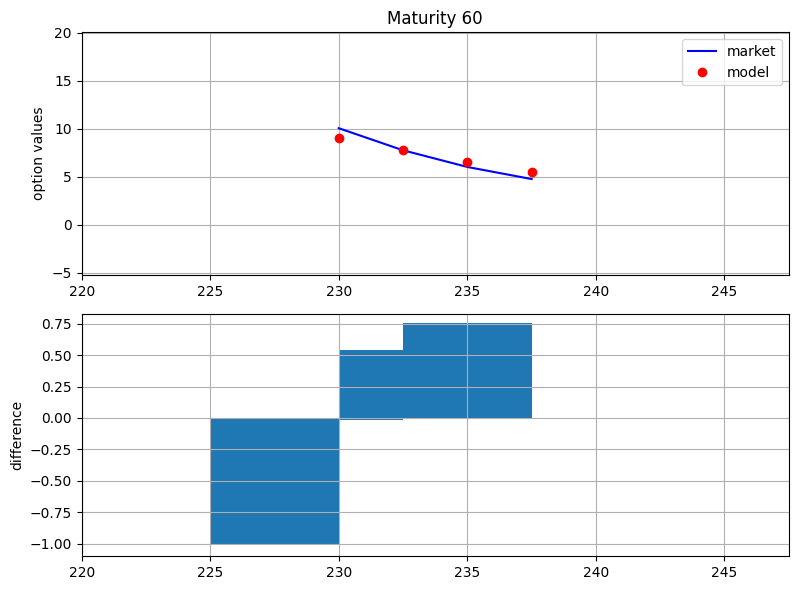

In [ ]:
plot_calibration_results(params1)

In [ ]:
print ("THE Call option value: ")
B96_call_value(S0, K, T, r, kappa_v, theta_v, sigma_v, rho, v0, lamb, mu, delta)

THE Call option value: 


<ipython-input-50-e06401f36e4a>:32: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  int_value = quad(


np.float64(7.536012380481338)

**Full Bates model calibration**

In [ ]:
p0 = [kappa_v, theta_v, sigma_v, rho, v0, lamb, mu, delta]
p0

[3.0473,
 0.12475,
 4.1087e-06,
 0.61562,
 0.10335,
 0.01924651,
 -0.59999983,
 0.00162885]

In [ ]:
i = 0
min_MSE = 5000.0

def B96_full_error_function(p0):
    global i, min_MSE
    kappa_v, theta_v, sigma_v, rho, v0, lamb, mu, delta = p0

    if (
        kappa_v < 0.0
        or theta_v < 0.005
        or sigma_v < 0.0
        or rho < -1.0
        or rho > 1.0
        or v0 < 0.0
        or lamb < 0.0
        or mu < -0.6
        or mu > 0.0
        or delta < 0.0
    ):
        return 5000.0

    if 2 * kappa_v * theta_v < sigma_v**2:
        return 5000.0

    se = []
    for row, option in option_data_step21.iterrows():
        model_value = B96_call_value(
            S0,
            option["Strike"],
            option["T"],
            option["r"],
            kappa_v,
            theta_v,
            sigma_v,
            rho,
            v0,
            lamb,
            mu,
            delta,
        )
        se.append((model_value - option["Call"]) ** 2)

    MSE = sum(se) / len(se)
    min_MSE = min(min_MSE, MSE)
    if i % 25 == 0:
        print("%4d |" % i, np.array(p0), "| %7.3f | %7.3f" % (MSE, min_MSE))
    i += 1
    return MSE

In [ ]:
def B96_calibration_full():
    opt = fmin(
        B96_full_error_function, p0, xtol=0.001, ftol=0.001, maxiter=1250, maxfun=650
    )
    return opt

In [ ]:
def B96_calculate_model_values(p0):
    kappa_v, theta_v, sigma_v, rho, v0, lamb, mu, delta = p0
    values = []
    for row, option in option_data_step21.iterrows():
        model_value = B96_call_value(
            S0,
            option["Strike"],
            option["T"],
            option["r"],
            kappa_v,
            theta_v,
            sigma_v,
            rho,
            v0,
            lamb,
            mu,
            delta,
        )

        values.append(model_value)

    return np.array(values)

In [ ]:
full_params = B96_calibration_full()

<ipython-input-50-e06401f36e4a>:32: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  int_value = quad(


   0 | [ 3.0473000e+00  1.2475000e-01  4.1087000e-06  6.1562000e-01
  1.0335000e-01  1.9246510e-02 -5.9999983e-01  1.6288500e-03] |   0.467 |   0.467
  25 | [ 3.06765693e+00  1.22609103e-01  4.16780901e-06  6.22679968e-01
  1.02230670e-01  1.97142284e-02 -5.91507643e-01  1.65608584e-03] |   0.463 |   0.462
  50 | [ 3.02397570e+00  1.22536495e-01  4.08008980e-06  6.10779964e-01
  1.01478494e-01  2.02445444e-02 -5.90880408e-01  1.65709372e-03] |   0.462 |   0.462
  75 | [ 2.89300764e+00  1.25414871e-01  3.86025156e-06  5.91205890e-01
  1.00709990e-01  2.25926739e-02 -5.75608545e-01  1.53592689e-03] |   0.461 |   0.461
 100 | [ 2.11808750e+00  1.50543954e-01  1.72164228e-06  6.25617095e-01
  9.87830145e-02  3.21160969e-02 -5.21372283e-01  1.15536201e-03] |   0.459 |   0.459


<ipython-input-50-e06401f36e4a>:32: IntegrationWarning: The maximum number of subdivisions (250) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  int_value = quad(


 125 | [ 1.92699376e+00  1.58740199e-01  9.80217630e-09  5.97169051e-01
  9.85884867e-02  4.05155309e-02 -4.70938684e-01  8.58527640e-04] |  54.937 |   0.454
 150 | [ 1.95718544e+00  1.56839965e-01  5.25574033e-07  6.08706047e-01
  9.88952678e-02  3.85138083e-02 -4.84485769e-01  8.96573069e-04] |   0.457 |   0.454
 175 | [ 1.94407037e+00  1.57781352e-01  3.76542342e-07  6.04390764e-01
  9.88761516e-02  3.91423365e-02 -4.80898419e-01  8.75651961e-04] |   0.457 |   0.454
 200 | [ 1.95722969e+00  1.57787125e-01  3.23148366e-07  6.06707552e-01
  9.89330771e-02  3.91689771e-02 -4.80705863e-01  8.79093886e-04] |   0.457 |   0.454
 225 | [ 1.95636535e+00  1.57820645e-01  3.21446796e-07  6.06733715e-01
  9.89323336e-02  3.91710088e-02 -4.80720638e-01  8.78973199e-04] |   0.457 |   0.454
 250 | [ 1.95586700e+00  1.57851062e-01  3.19318820e-07  6.06933727e-01
  9.89277402e-02  3.91761982e-02 -4.80695573e-01  8.78662080e-04] |   0.457 |   0.454
 275 | [ 1.95593003e+00  1.57850203e-01  3.19956287e

<ipython-input-67-0fb35a4aa397>:2: RuntimeWarning: Maximum number of function evaluations has been exceeded.
  opt = fmin(


In [ ]:
def plot_full_calibration_results(p0):
    option_data_step21["Model"] = B96_calculate_model_values(p0)
    plt.figure(figsize=(8, 6))
    plt.subplot(211)
    plt.grid()
    plt.title("Maturity %s" % str(option_data_step21["Days to Maturity"].iloc[0])[:10])
    plt.ylabel("option values")
    plt.plot(option_data_step21.Strike, option_data_step21.Call, "b", label="market")
    plt.plot(option_data_step21.Strike, option_data_step21.Model, "ro", label="model")
    plt.legend(loc=0)
    plt.axis(
        [
            min(option_data_step21.Strike) - 10,
            max(option_data_step21.Strike) + 10,
            min(option_data_step21.Call) - 10,
            max(option_data_step21.Call) + 10,
        ]
    )
    plt.subplot(212)
    plt.grid()
    wi = 5.0
    diffs = option_data_step21.Model.values - option_data_step21.Call.values
    plt.bar(option_data_step21.Strike.values - wi / 2, diffs, width=wi)
    plt.ylabel("difference")
    plt.axis(
        [
            min(option_data_step21.Strike) - 10,
            max(option_data_step21.Strike) + 10,
            min(diffs) * 1.1,
            max(diffs) * 1.1,
        ]
    )
    plt.tight_layout()

In [ ]:
def plot_calibration_results(p0):
    option_data_step21["Model"] = B96_jump_calculate_model_values(p0)
    plt.figure(figsize=(8, 6))
    plt.subplot(211)
    plt.grid()
    plt.title("Maturity %s" % str(option_data_step21["Days to Maturity"].iloc[0])[:10])
    plt.ylabel("option values")
    plt.plot(option_data_step21.Strike, option_data_step21.Call, "b", label="market")
    plt.plot(option_data_step21.Strike, option_data_step21.Model, "ro", label="model")
    plt.legend(loc=0)
    plt.axis(
        [
            min(option_data_step21.Strike) - 10,
            max(option_data_step21.Strike) + 10,
            min(option_data_step21.Call) - 10,
            max(option_data_step21.Call) + 10,
        ]
    )
    plt.subplot(212)
    plt.grid()
    wi = 5.0
    diffs = option_data_step21.Model.values -option_data_step21.Call.values
    plt.bar(option_data_step21.Strike.values - wi / 2, diffs, width=wi)
    plt.ylabel("difference")
    plt.axis(
        [
            min(option_data_step21.Strike) - 10,
            max(option_data_step21.Strike) + 10,
            min(diffs) * 1.1,
            max(diffs) * 1.1,
        ]
    )
    plt.tight_layout()

<ipython-input-50-e06401f36e4a>:32: IntegrationWarning: The maximum number of subdivisions (250) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  int_value = quad(


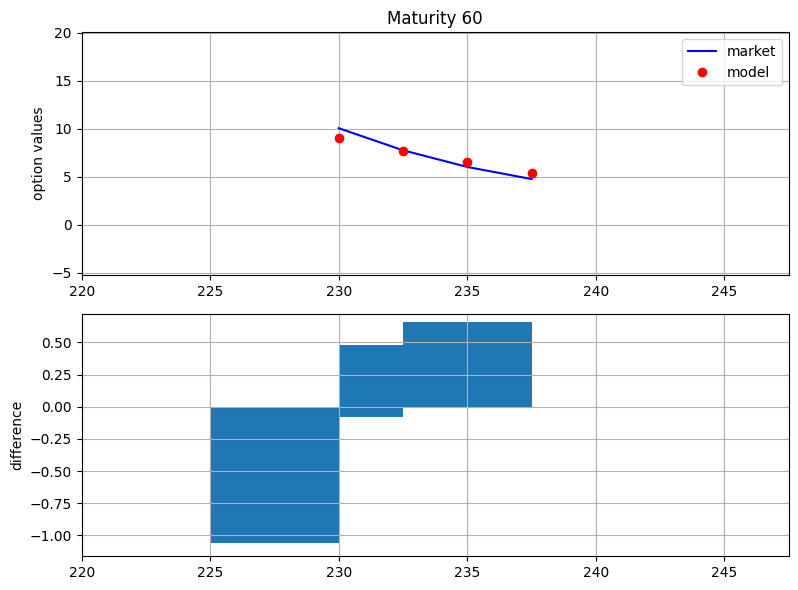

In [ ]:
plot_full_calibration_results(full_params)

step 2b) Option Prcing and model calibration using Carr-Madan approach to Bates (1996)

In [ ]:
# Heston characteristic equation
def H93_char_func(u, T, r, kappa_v, theta_v, sigma_v, rho, v0):
    """Valuation of European call option in H93 model via Lewis (2001)
    Fourier-based approach: characteristic function.
    Parameter definitions see function BCC_call_value."""
    c1 = kappa_v * theta_v
    c2 = -np.sqrt(
        (rho * sigma_v * u * 1j - kappa_v) ** 2 - sigma_v**2 * (-u * 1j - u**2)
    )
    c3 = (kappa_v - rho * sigma_v * u * 1j + c2) / (
        kappa_v - rho * sigma_v * u * 1j - c2
    )
    H1 = r * u * 1j * T + (c1 / sigma_v**2) * (
        (kappa_v - rho * sigma_v * u * 1j + c2) * T
        - 2 * np.log((1 - c3 * np.exp(c2 * T)) / (1 - c3))
    )
    H2 = (
        (kappa_v - rho * sigma_v * u * 1j + c2)
        / sigma_v**2
        * ((1 - np.exp(c2 * T)) / (1 - c3 * np.exp(c2 * T)))
    )
    char_func_value = np.exp(H1 + H2 * v0)
    return char_func_value

In [ ]:
# Adjusteed Merton model
def M76J_char_func(u, T, lamb, mu, delta):
    """
    Adjusted Characteristic function for Merton '76 model: Only jump component
    """

    omega = -lamb * (np.exp(mu + 0.5 * delta**2) - 1)
    char_func_value = np.exp(
        (1j * u * omega + lamb * (np.exp(1j * u * mu - u**2 * delta**2 * 0.5) - 1))
        * T
    )
    return char_func_value

In [ ]:
# Bates characteristic function
def B96_char_func(u, T, r, kappa_v, theta_v, sigma_v, rho, v0, lamb, mu, delta):
    """
    Bates (1996) characteristic function
    """
    H93 = H93_char_func(u, T, r, kappa_v, theta_v, sigma_v, rho, v0)
    M76J = M76J_char_func(u, T, lamb, mu, delta)
    return H93 * M76J

In [ ]:
def H93_int_func(u, S0, K, T, r, kappa_v, theta_v, sigma_v, rho, v0):
    """
    Fourier-based approach for Lewis (2001): Integration function.
    """
    char_func_value = H93_char_func(
        u - 1j * 0.5, T, r, kappa_v, theta_v, sigma_v, rho, v0
    )
    int_func_value = (
        1 / (u**2 + 0.25) * (np.exp(1j * u * np.log(S0 / K)) * char_func_value).real
    )
    return int_func_value

In [ ]:
def H93_call_value(S0, K, T, r, kappa_v, theta_v, sigma_v, rho, v0):
    """Valuation of European call option in H93 model via Lewis (2001)

    Parameter definition:
    ==========
    S0: float
        initial stock/index level
    K: float
        strike price
    T: float
        time-to-maturity (for t=0)
    r: float
        constant risk-free short rate
    kappa_v: float
        mean-reversion factor
    theta_v: float
        long-run mean of variance
    sigma_v: float
        volatility of variance
    rho: float
        correlation between variance and stock/index level
    v0: float
        initial level of variance
    Returns
    =======
    call_value: float
        present value of European call option
    """
    int_value = quad(
        lambda u: H93_int_func(u, S0, K, T, r, kappa_v, theta_v, sigma_v, rho, v0),
        0,
        np.inf,
        limit=250,
    )[0]
    call_value = max(0, S0 - np.exp(-r * T) * np.sqrt(S0 * K) / np.pi * int_value)
    return call_value

In [ ]:
# define the error function
i = 0
min_MSE = 500

def H93_error_function(p0):
    """Error function for parameter calibration via
    Lewis (2001) Fourier approach for Heston (1993).
    Parameters
    ==========
    kappa_v: float
        mean-reversion factor
    theta_v: float
        long-run mean of variance
    sigma_v: float
        volatility of variance
    rho: float
        correlation between variance and stock/index level
    v0: float
        initial, instantaneous variance
    Returns
    =======
    MSE: float
        mean squared error
    """
    global i, min_MSE
    kappa_v, theta_v, sigma_v, rho, v0 = p0
    if kappa_v < 0.0 or theta_v < 0.005 or sigma_v < 0.0 or rho < -1.0 or rho > 1.0:
        return 500.0
    if 2 * kappa_v * theta_v < sigma_v**2:
        return 500.0
    se = []
    for row, option in options.iterrows():
        model_value = H93_call_value(
            S0,
            option["Strike"],
            option["T"],
            option["r"],
            kappa_v,
            theta_v,
            sigma_v,
            rho,
            v0,
        )
        se.append((model_value - option["Call"]) ** 2)
    MSE = sum(se) / len(se)
    min_MSE = min(min_MSE, MSE)
    if i % 25 == 0:
        print("%4d |" % i, np.array(p0), "| %7.3f | %7.3f" % (MSE, min_MSE))
    i += 1
    return MSE

In [ ]:
def H93_calibration_full():
    """Calibrates Heston (1993) stochastic volatility model to market quotes."""
    # First run with brute force
    # (scan sensible regions, for faster convergence)
    p0 = brute(
        H93_error_function,
        (
            (2.5, 10.6, 5.0),  # kappa_v
            (0.01, 0.041, 0.01),  # theta_v
            (0.05, 0.251, 0.1),  # sigma_v
            (-0.75, 0.01, 0.25),  # rho
            (0.01, 0.031, 0.01),
        ),  # v0
        finish=None,
    )

    # Second run with local, convex minimization
    # (we dig deeper where promising results)
    opt = fmin(
        H93_error_function, p0, xtol=0.000001, ftol=0.000001, maxiter=750, maxfun=900
    )
    return opt

In [ ]:
params= H93_calibration_full()

   0 | [ 2.5   0.01  0.05 -0.75  0.01] |  23.560 |  23.560
  25 | [ 2.5   0.02  0.05 -0.75  0.02] |  16.264 |  11.964
  50 | [ 2.5   0.02  0.25 -0.75  0.03] |  11.689 |  11.662
  75 | [ 2.5   0.03  0.15 -0.5   0.01] |  22.320 |  11.367
 100 | [ 2.5   0.04  0.05 -0.5   0.02] |  15.462 |  11.089
 125 | [ 2.5   0.04  0.25 -0.5   0.03] |  11.135 |  11.079
 150 | [ 7.5   0.01  0.15 -0.25  0.01] |  23.608 |  11.079
 175 | [ 7.5   0.02  0.05 -0.25  0.02] |  16.283 |  11.079
 200 | [ 7.5   0.02  0.25 -0.25  0.03] |  12.271 |  11.079
 225 | [7.5  0.03 0.15 0.   0.01] |  20.385 |  11.079
 250 | [7.5  0.04 0.05 0.   0.02] |  14.175 |  10.608
 275 | [7.5  0.04 0.25 0.   0.03] |  10.699 |  10.597
 300 | [ 7.10037179  0.05742843  0.11352214 -0.46596154  0.04611934] |   5.735 |   5.735
 325 | [4.40533337 0.12535142 0.0295268  0.88059866 0.1090853 ] |   0.422 |   0.387
 350 | [4.61442166 0.12165979 0.0273206  0.75145539 0.10338613] |   0.382 |   0.382
 375 | [4.59781487 0.12096663 0.02707868 0.7266005

<ipython-input-77-277e0d7e46d1>:29: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  int_value = quad(


 425 | [3.11416214e+00 1.24592879e-01 1.05443179e-03 6.16838223e-01
 1.03272892e-01] |   0.378 |   0.378
 450 | [3.05816719e+00 1.24815986e-01 2.59029072e-05 6.11844876e-01
 1.03346090e-01] |   0.378 |   0.378
 475 | [3.04884645e+00 1.24761041e-01 2.89505546e-06 6.14850388e-01
 1.03345140e-01] |   0.378 |   0.378
 500 | [3.04750647e+00 1.24755280e-01 4.34807211e-06 6.15508253e-01
 1.03348326e-01] |   0.378 |   0.378
 525 | [3.04732482e+00 1.24756830e-01 4.11644132e-06 6.15624254e-01
 1.03350321e-01] |   0.378 |   0.378
 550 | [3.04732015e+00 1.24756684e-01 4.10274251e-06 6.15622837e-01
 1.03350233e-01] |   0.378 |   0.378
 575 | [3.04732613e+00 1.24756721e-01 4.11084266e-06 6.15620735e-01
 1.03350232e-01] |   0.378 |   0.378
 600 | [3.04732415e+00 1.24756712e-01 4.10885546e-06 6.15621511e-01
 1.03350235e-01] |   0.378 |   0.378
 625 | [3.04732412e+00 1.24756711e-01 4.10869046e-06 6.15621494e-01
 1.03350234e-01] |   0.378 |   0.378
 650 | [3.04732414e+00 1.24756711e-01 4.10870391e-06 6.

In [ ]:
# Carr Merden Pricing function
def B96_call_FFT(S0, K, T, r, kappa_v, theta_v, sigma_v, rho, v0, lamb, mu, delta):
    """
    Call option price in Bates (1996) under FFT
    """

    k = np.log(K / S0)
    g = 1  # Factor to increase accuracy
    N = g * 4096
    eps = (g * 150) ** -1
    eta = 2 * np.pi / (N * eps)
    b = 0.5 * N * eps - k
    u = np.arange(1, N + 1, 1)
    vo = eta * (u - 1)

    # Modifications to ensure integrability
    if S0 >= 0.95 * K:  # ITM Case
        alpha = 1.5
        v = vo - (alpha + 1) * 1j
        modcharFunc = np.exp(-r * T) * (
            B96_char_func(v, T, r, kappa_v, theta_v, sigma_v, rho, v0, lamb, mu, delta)
            / (alpha**2 + alpha - vo**2 + 1j * (2 * alpha + 1) * vo)
        )

    else:
        alpha = 1.1
        v = (vo - 1j * alpha) - 1j
        modcharFunc1 = np.exp(-r * T) * (
            1 / (1 + 1j * (vo - 1j * alpha))
            - np.exp(r * T) / (1j * (vo - 1j * alpha))
            - B96_char_func(
                v, T, r, kappa_v, theta_v, sigma_v, rho, v0, lamb, mu, delta
            )
            / ((vo - 1j * alpha) ** 2 - 1j * (vo - 1j * alpha))
        )

        v = (vo + 1j * alpha) - 1j

        modcharFunc2 = np.exp(-r * T) * (
            1 / (1 + 1j * (vo + 1j * alpha))
            - np.exp(r * T) / (1j * (vo + 1j * alpha))
            - B96_char_func(
                v, T, r, kappa_v, theta_v, sigma_v, rho, v0, lamb, mu, delta
            )
            / ((vo + 1j * alpha) ** 2 - 1j * (vo + 1j * alpha))
        )

    # Numerical FFT Routine
    delt = np.zeros(N)
    delt[0] = 1
    j = np.arange(1, N + 1, 1)
    SimpsonW = (3 + (-1) ** j - delt) / 3
    if S0 >= 0.95 * K:
        FFTFunc = np.exp(1j * b * vo) * modcharFunc * eta * SimpsonW
        payoff = (np.fft.fft(FFTFunc)).real
        CallValueM = np.exp(-alpha * k) / np.pi * payoff
    else:
        FFTFunc = (
            np.exp(1j * b * vo) * (modcharFunc1 - modcharFunc2) * 0.5 * eta * SimpsonW
        )
        payoff = (np.fft.fft(FFTFunc)).real
        CallValueM = payoff / (np.sinh(alpha * k) * np.pi)

    pos = int((k + b) / eps)
    CallValue = CallValueM[pos] * S0

    return CallValue

In [ ]:
i = 0
min_MSE = 5000.0
local_opt = False

def B96_error_function(p0):
    """
    Error function for Bates (1996) model

    Parameters:
    -------------
    lamb: float
        jump intensity
    mu: float
        expected jump size
    delta: float
        standard deviation of jump
    Returns
    -------------
    MSE: float
        mean squared error
    """

    global i, min_MSE, local_opt, opt1
    lamb, mu, delta = p0
    if lamb < 0.0 or mu < -0.6 or mu > 0.0 or delta < 0.0:
        return 5000.0
    se = []
    for row, option in options.iterrows():
        model_value = B96_call_FFT(
            S0,
            option["Strike"],
            option["T"],
            option["r"],
            kappa_v,
            theta_v,
            sigma_v,
            rho,
            v0,
            lamb,
            mu,
            delta,
        )
        se.append((model_value - option["Call"]) ** 2)
    MSE = sum(se) / len(se)
    min_MSE = min(min_MSE, MSE)
    if i % 25 == 0:
        print("%4d |" % i, np.array(p0), "| %7.3f | %7.3f" % (MSE, min_MSE))
    i += 1
    if local_opt:
        penalty = np.sqrt(np.sum((p0 - opt1) ** 2)) * 1
        return MSE + penalty
    return MSE

In [ ]:
def B96_calibration_short():
    """
    Calibrates jump component of Bates (1996) model to market prices
    """
    # First, we run with brute force
    # (scan sensible regions)
    opt1 = 0.0
    opt1 = brute(
        B96_error_function,
        (
            (0.0, 0.51, 0.1),  # lambda
            (-0.5, -0.11, 0.1),  # mu
            (0.0, 0.51, 0.25),
        ),  # delta
        finish=None,
    )

    # Second, we run with local, convex minimization
    # (dig deeper where promising)
    opt2 = fmin(
        B96_error_function,
        opt1,
        xtol=0.0000001,
        ftol=0.0000001,
        maxiter=550,
        maxfun=750,
    )
    return opt2

In [ ]:
params2 = B96_calibration_short()

   0 | [ 0.  -0.5  0. ] |   0.378 |   0.378
  25 | [ 0.2  -0.5   0.25] |   0.551 |   0.377
  50 | [ 0.4 -0.5  0.5] |   1.426 |   0.377
  75 | [ 0.1     -0.2      0.00025] |   0.377 |   0.377
 100 | [ 0.02715778 -0.30358414  0.00074493] |   0.375 |   0.375
 125 | [ 2.62536065e-02 -4.21857689e-01  2.46295112e-04] |   0.374 |   0.374
 150 | [ 2.06033535e-02 -5.80260195e-01  9.25934349e-05] |   0.374 |   0.374
 175 | [ 2.06293247e-02 -5.99853877e-01  5.06992082e-06] |   0.374 |   0.374
 200 | [ 2.06726435e-02 -5.99984082e-01  6.69910869e-07] |   0.374 |   0.374
 225 | [ 2.06997596e-02 -5.99996571e-01  6.14160586e-08] |   0.374 |   0.374
 250 | [ 2.10256214e-02 -5.99959563e-01  1.52571045e-06] |   0.374 |   0.374
 275 | [ 2.09370473e-02 -5.99997621e-01  9.36558028e-07] |   0.374 |   0.374
 300 | [ 2.09297910e-02 -5.99999952e-01  9.25149212e-07] |   0.374 |   0.374
 325 | [ 2.09292687e-02 -5.99999999e-01  9.33148339e-07] |   0.374 |   0.374
Optimization terminated successfully.
         Curr

In [ ]:
lamb= params2[0]
mu= params2[1]
delta= params2[2]

In [ ]:
def B96_jump_calculate_model_values(p0):
    """Calculates all model values given parameter vector p0."""
    lamb, mu, delta = p0
    values = []
    for row, option in options.iterrows():

        model_value = B96_call_FFT(
            S0,
            option["Strike"],
            option["T"],
            option["r"],
            kappa_v,
            theta_v,
            sigma_v,
            rho,
            v0,
            lamb,
            mu,
            delta,
        )
        values.append(model_value)
    return np.array(values)

In [ ]:
def plot_calibration_results(p0):
    options["Model"] = B96_jump_calculate_model_values(p0)
    plt.figure(figsize=(8, 6))
    plt.subplot(211)
    plt.grid()
    plt.title("Maturity %s" % str(options["Days to Maturity"].iloc[0])[:10])
    plt.ylabel("option values")
    plt.plot(options.Strike, options.Call, "b", label="market")
    plt.plot(options.Strike, options.Model, "ro", label="model")
    plt.legend(loc=0)
    plt.axis(
        [
            min(options.Strike) - 10,
            max(options.Strike) + 10,
            min(options.Call) - 10,
            max(options.Call) + 10,
        ]
    )
    plt.subplot(212)
    plt.grid()
    wi = 5.0
    diffs = options.Model.values - options.Call.values
    plt.bar(options.Strike.values - wi / 2, diffs, width=wi)
    plt.ylabel("difference")
    plt.axis(
        [
            min(options.Strike) - 10,
            max(options.Strike) + 10,
            min(diffs) * 1.1,
            max(diffs) * 1.1,
        ]
    )
    plt.tight_layout()

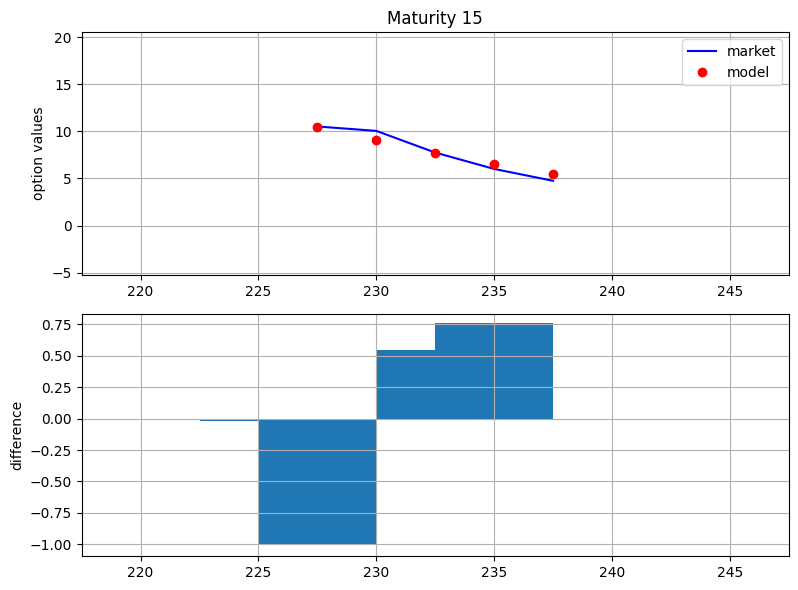

In [ ]:
plot_calibration_results(params2)

**Step 3**

In [ ]:
mat_list = np.array((7, 30, 90, 180, 360)) / 360
rate_list = (
    np.array((0.648, 0.679, 1.173, 1.809, 2.556)) / 100
)

Then we defined the current interest rates, the capitalization factors and the zero-forward rates implied by the Euribor rates observed from the data.

In [ ]:
r0 = rate_list[0]
factors = 1 + mat_list * rate_list
zero_rates = 1 / mat_list * np.log(factors)

Then we plotted the forward rates and their maturities to observe tha pattern

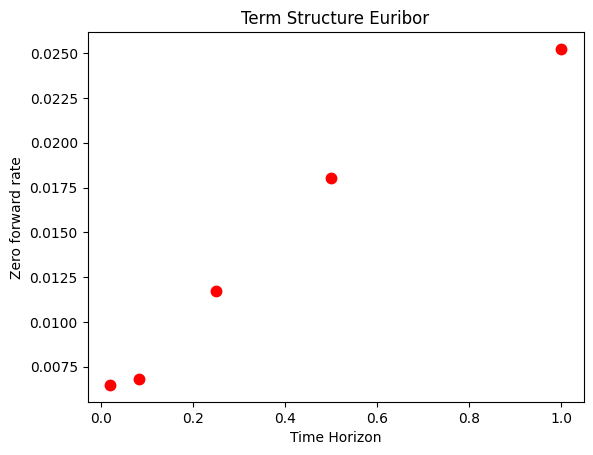

In [ ]:
plt.plot(mat_list, zero_rates, "r.", markersize="15")
plt.xlabel("Time Horizon")
plt.ylabel("Zero forward rate")
plt.title("Term Structure Euribor")
plt.show()

In [ ]:
bspline = splrep(mat_list, zero_rates, k=3)  # Cubic spline
mat_list_n = np.linspace(
    0.0, 1.0, 24
)  # Create 24 equally spaced maturities between 0 and 1
inter_rates = splev(mat_list_n, bspline, der=0)  # Interpolated rates

first_der = splev(mat_list_n, bspline, der=1)  # First derivative of spline
f = (
    inter_rates + first_der * mat_list_n
)  # Forward rate given interpolated ones and first derivative

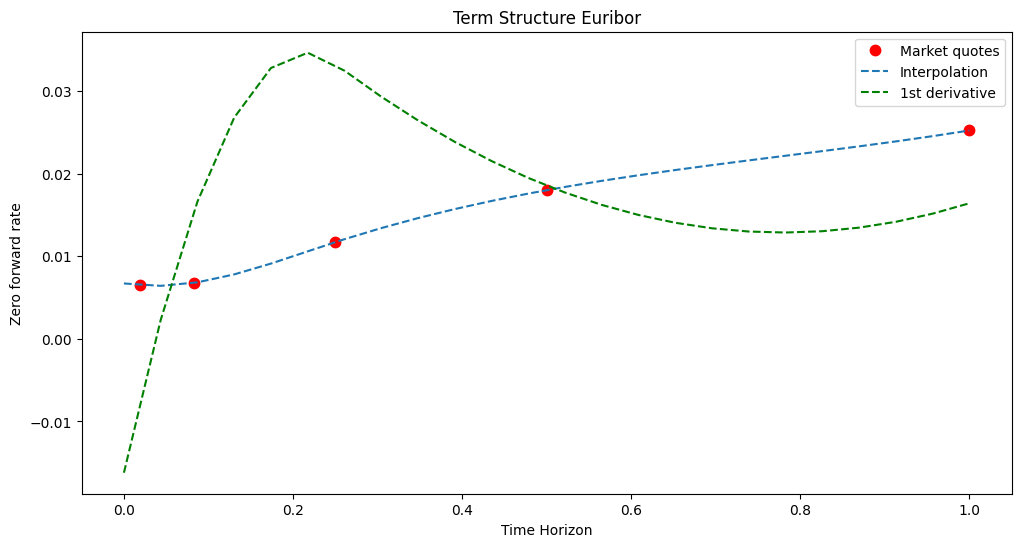

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(mat_list, zero_rates, "r.", markersize="15", label="Market quotes")
plt.plot(mat_list_n, inter_rates, "--", markersize="10", label="Interpolation")
plt.plot(mat_list_n, first_der, "g--", markersize="10", label="1st derivative")
plt.xlabel("Time Horizon")
plt.ylabel("Zero forward rate")
plt.title("Term Structure Euribor")
plt.legend()
plt.show()

In [ ]:
def CIR_forward_rate(alpha):
    """
    Forward rates in CIR (1985) model
    The set of parameters is called alpha and include Kappa_r, Theta_r and Sigma_r
    """

    kappa_r, theta_r, sigma_r = alpha

    t = mat_list_n
    g = np.sqrt(kappa_r**2 + 2 * sigma_r**2)

    s1 = (kappa_r * theta_r * (np.exp(g * t) - 1)) / (
        2 * g + (kappa_r + g) * (np.exp(g * t) - 1)
    )

    s2 = r0 * (
        (4 * g**2 * np.exp(g * t)) / (2 * g + (kappa_r + g) * (np.exp(g * t)) ** 2)
    )

    return s1 + s2

In [ ]:
def CIR_error_function(alpha):
    """
    Error function to calibrate CIR (1985) model
    """

    kappa_r, theta_r, sigma_r = alpha

    # Few remarks to avoid problems for certain values of parameters:
    if 2 * kappa_r * theta_r < sigma_r**2:
        return 100
    if kappa_r < 0 or theta_r < 0 or sigma_r < 0.001:
        return 100

    forward_rates = CIR_forward_rate(alpha)
    MSE = np.sum((f - forward_rates) ** 2) / len(f)

    return MSE

In [ ]:
def CIR_calibration():
    opt = fmin(
        CIR_error_function,
        [1.0, 0.02, 0.1],
        xtol=0.00001,
        ftol=0.00001,
        maxiter=300,
        maxfun=500,
    )

    return opt

In [ ]:
params = CIR_calibration()

Optimization terminated successfully.
         Current function value: 0.000003
         Iterations: 161
         Function evaluations: 288


In [ ]:
params

array([0.98908305, 0.10863186, 0.00100074])

Calibration Parameters

κr=0.989

θr=0.108

σr=0.001

In [ ]:
def plot_calibrated_frc(opt):
    """Plots market and calibrated forward rate curves."""
    forward_rates = CIR_forward_rate(opt)
    plt.figure(figsize=(12, 8))
    plt.subplot(211)
    plt.title("CIR model calibration")
    plt.ylabel("Forward rate $f(0,T)$")
    plt.plot(mat_list_n, f, "ro", label="market")
    plt.plot(mat_list_n, forward_rates, "b--", label="model")
    plt.legend(loc=0)
    plt.axis(
        [min(mat_list_n) - 0.05, max(mat_list_n) + 0.05, min(f) - 0.005, max(f) * 1.1]
    )
    plt.subplot(212)
    wi = 0.02
    plt.bar(mat_list_n - wi / 2, forward_rates - f, width=wi)
    plt.xlabel("Time horizon")
    plt.ylabel("Difference")
    plt.axis(
        [
            min(mat_list_n) - 0.05,
            max(mat_list_n) + 0.05,
            min(forward_rates - f) * 1.1,
            max(forward_rates - f) * 1.1,
        ]
    )
    plt.tight_layout()

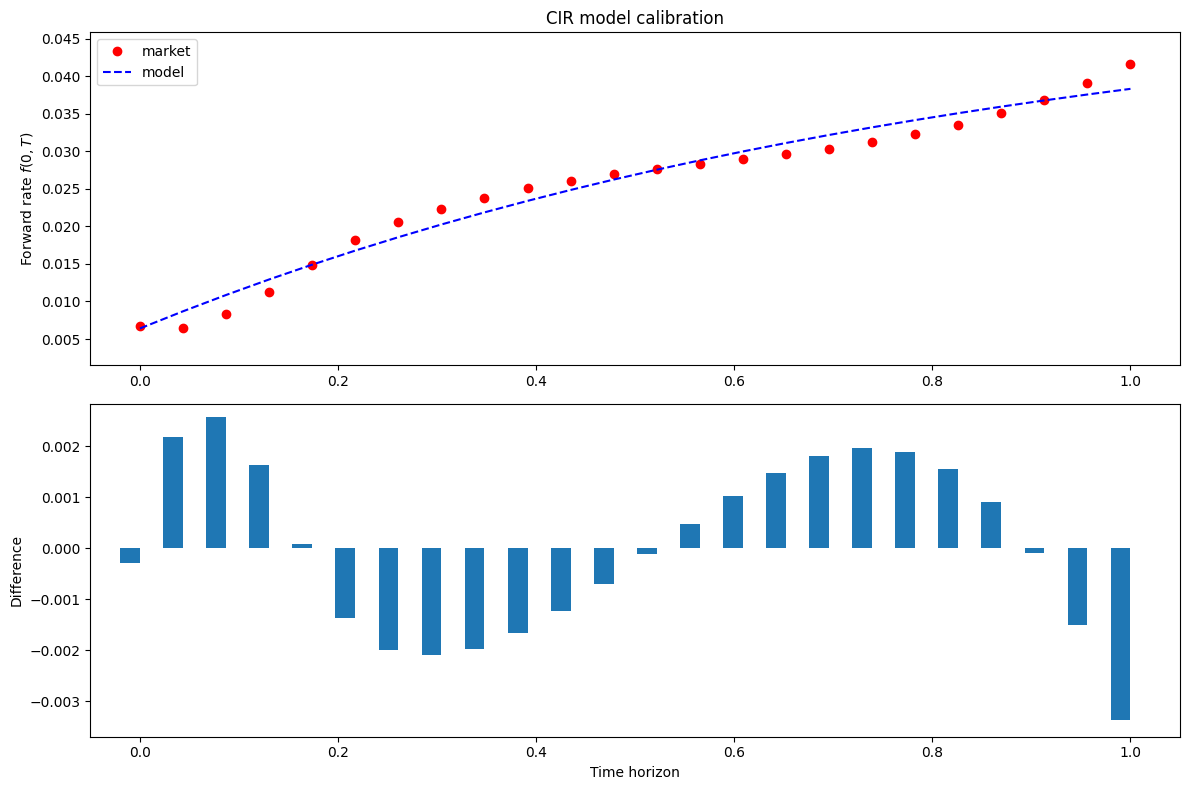

In [ ]:
plot_calibrated_frc(params)

b) Determining the range that Euribor interest rates can take in the next 12 months using 95% confidence level

In [ ]:
# Parameters from CIR calibration
kappa_r, theta_r, sigma_r = params
r0 = rate_list[0]  # Initial interest rate

# Simulation parameters
num_simulations = 100000
num_days = 250  # Number of days in a year
dt = 1 / num_days  # Time step

# Initialize the interest rate matrix
interest_rates = np.zeros((num_simulations, num_days + 1))
interest_rates[:, 0] = r0

# Perform Monte Carlo simulation
for t in range(num_days):
    Z = np.random.normal(size=num_simulations)  # Standard normal random variable
    interest_rates[:, t + 1] = interest_rates[:, t] + kappa_r * (theta_r - interest_rates[:, t]) * dt + sigma_r * np.sqrt(np.maximum(0, interest_rates[:, t])) * np.sqrt(dt) * Z

In [ ]:
confidence_level = 0.95  # Example: 95% confidence level

# Calculate the mean and standard deviation of the simulated interest rates at the end of the year
mean_rate = np.mean(interest_rates[:, -1])
std_rate = np.std(interest_rates[:, -1])

# Calculate the confidence interval
lower_bound = mean_rate - 1.96 * std_rate  # For a 95% confidence level, the z-score is 1.96
upper_bound = mean_rate + 1.96 * std_rate

print(f"With {confidence_level * 100:.0f}% confidence, the 12-month Euribor can take values between {lower_bound:.4f} and {upper_bound:.4f} in the next year.")

With 95% confidence, the 12-month Euribor can take values between 0.0704 and 0.0710 in the next year.


In [ ]:
# Calculate the expected value
average_rate = np.mean(interest_rates[:, -1])
print(f"Average Euribor rate at the end of the year: {average_rate:.4f}")

Average Euribor rate at the end of the year: 0.0707


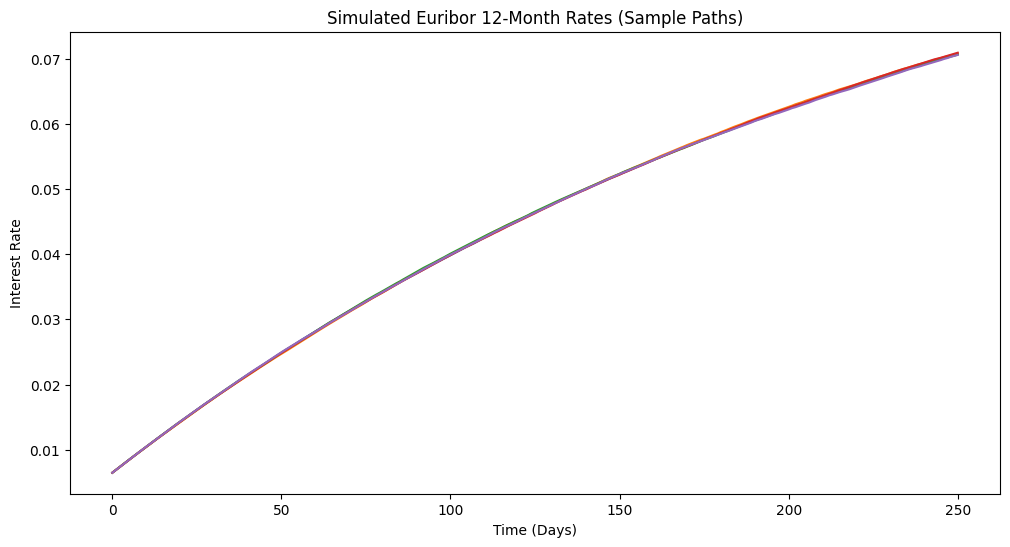

In [ ]:
# Plot a few sample paths of the simulated interest rates
plt.figure(figsize=(12, 6))
for i in range(5):  # Plot the first 5 simulations
  plt.plot(interest_rates[i, :])
plt.xlabel('Time (Days)')
plt.ylabel('Interest Rate')
plt.title('Simulated Euribor 12-Month Rates (Sample Paths)')
plt.show()

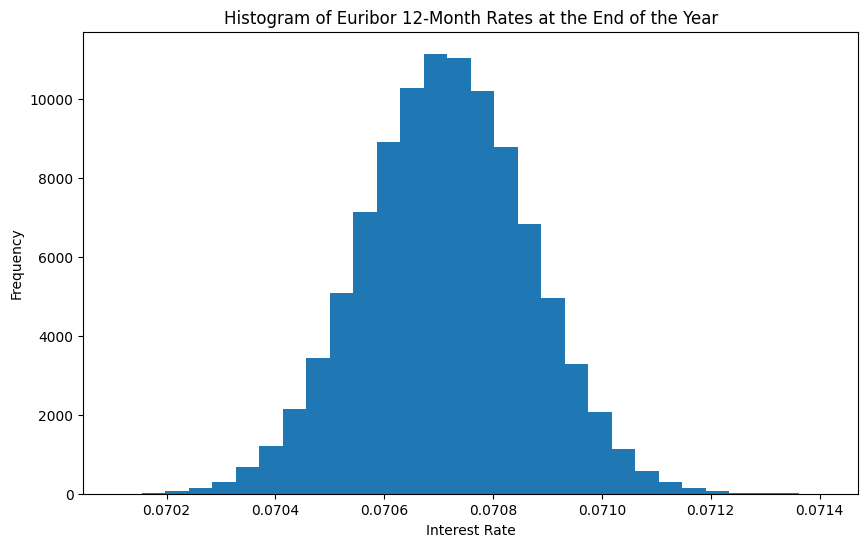

In [ ]:
#Histograms of the interest rate at specific time points
plt.figure(figsize=(10, 6))
plt.hist(interest_rates[:, -1], bins=30)
plt.xlabel('Interest Rate')
plt.ylabel('Frequency')
plt.title('Histogram of Euribor 12-Month Rates at the End of the Year')
plt.show()